# Showcase — the 2023 Canadian wildfires (FIRMS + Sentinel-2 dNBR)

2023 was Canada's worst fire season on record — about 10–14 million hectares burned (~4.7× the 1986–2022 average). This notebook combines NASA **FIRMS** active-fire detections with a **Sentinel-2 dNBR** burn-severity map rendered via pyramids' `Dataset.plot()`.

## What this notebook does

1. **FIRMS** — VIIRS active-fire detections over Quebec at the June 2023 peak (point map + per-day counts + FRP distribution, matplotlib — FIRMS is vector).
2. **dNBR** — Sentinel-2 before/after burn severity, rendered with `Dataset.plot()` and classified into USGS severity classes.

> Needs `FIRMS_MAP_KEY` for FIRMS and `GEE_SERVICE_ACCOUNT`/`GEE_SERVICE_KEY` + `pyramids-gis[viz]` for the Sentinel-2 cells; each part skips gracefully.

### Credentials

This notebook reads its credentials from a `.env` file at the repository root
(loaded with `python-dotenv` by the setup cell below; your `PATH` is left
untouched). Create that `.env` with at least:

```text
GEE_SERVICE_ACCOUNT="your-sa@your-project.iam.gserviceaccount.com"
GEE_SERVICE_KEY="/path/to/your/service-account-key.json"
FIRMS_MAP_KEY="your-free-NASA-FIRMS-map-key"   # for the active-fire layer
```


In [4]:
# credentials: load the repo-root .env with python-dotenv (PATH left untouched) ---
import os
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(usecwd=True))

SERVICE_ACCOUNT = os.environ["GEE_SERVICE_ACCOUNT"]
SERVICE_KEY = os.environ["GEE_SERVICE_KEY"]
FIRMS_MAP_KEY = os.environ["FIRMS_MAP_KEY"]
if any(x is None for x in (SERVICE_ACCOUNT, SERVICE_KEY, FIRMS_MAP_KEY)):
    raise ValueError("Missing credentials in .env")

In [5]:
import os, tempfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from loguru import logger
from earthlens import EarthLens
from pyramids.dataset import Dataset   # pyramids' own plotting

warnings.filterwarnings("ignore")
logger.remove()

# FIRMS returns a GeoDataFrame of fire pixels (vector) -> matplotlib scatter.
fires = EarthLens(
    data_source="firms",
    variables=["VIIRS_SNPP_SP"],
    start="2023-06-02",
    end="2023-06-08",
    aoi=[-80.0, 48.0, -72.0, 53.0],
    path=tempfile.mkdtemp()
).authenticate(api_key=FIRMS_MAP_KEY)
data = fires.download(progress_bar=False)
print(f"{len(data):,} fire detections")

2026-06-12 00:02:01 | INFO | pyramids.base.config | Logging is configured.
2026-06-12 00:02:11 | INFO | pyogrio._io | Created 24,702 records


24,702 fire detections


## Active-fire map and daily counts (FIRMS)

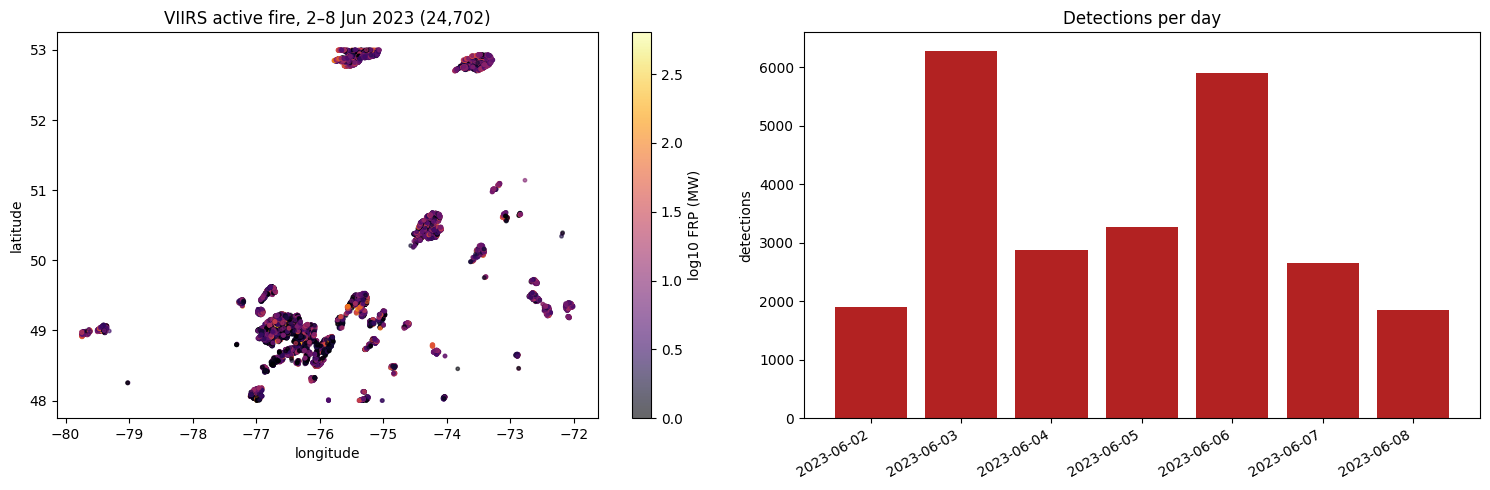

median FRP 7.3 MW | total 517.8 GW


In [2]:
if len(data):
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    sc = ax[0].scatter(
        data.longitude,
        data.latitude,
        c=np.log10(data.frp.clip(lower=1)),
        cmap="inferno",
        s=6,
        alpha=0.6
    )

    ax[0].set(xlabel="longitude", ylabel="latitude", title=f"VIIRS active fire, 2–8 Jun 2023 ({len(data):,})")
    fig.colorbar(sc, ax=ax[0], label="log10 FRP (MW)")
    d = pd.to_datetime(data.acq_datetime, utc=True).dt.date.value_counts().sort_index()
    ax[1].bar([str(x) for x in d.index], d.values, color="firebrick"); ax[1].set(ylabel="detections", title="Detections per day")
    plt.setp(ax[1].get_xticklabels(), rotation=30, ha="right"); plt.tight_layout(); plt.show()
    print(f"median FRP {data.frp.median():.1f} MW | total {data.frp.sum()/1e3:.1f} GW")

## Burn severity (dNBR) — `Dataset.plot()`

`NBR = (NIR − SWIR)/(NIR + SWIR)`; `dNBR = NBR_before − NBR_after` is the standard burn-severity index. The dNBR grid (derived) is wrapped back into a Dataset so it renders with `Dataset.plot()`; the severity-class areas are a matplotlib bar.

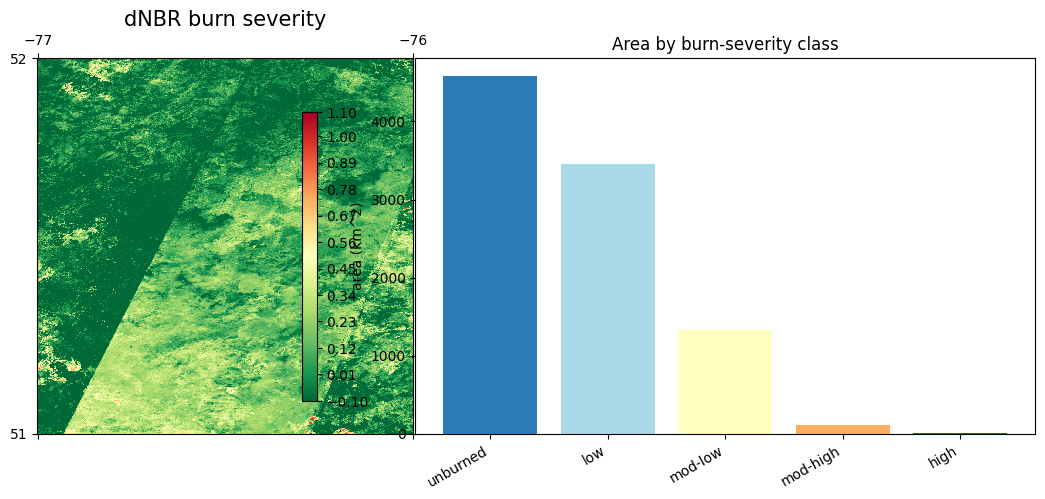

burned area in this tile: 4,906 km^2 (122 km^2 mod-high to high)


In [3]:
BURN_AOI = [-77.0, 51.0, -76.0, 52.0]
def nbr(start, end):
    p = EarthLens(data_source="gee", cadence="raw", path=tempfile.mkdtemp(), dataset="COPERNICUS/S2_SR_HARMONIZED", variables=["B8", "B12"], aoi=BURN_AOI, start=start, end=end, scale=80, reducer="median").load()[0]
    a = np.asarray(p.read_array(), dtype="float32"); return (a[0] - a[1]) / (a[0] + a[1] + 1e-6), p
nbr_pre, pp = nbr("2023-05-01", "2023-05-31"); nbr_post, _ = nbr("2023-09-01", "2023-09-30")

if nbr_pre is not None and nbr_post is not None:
    h, w = min(nbr_pre.shape[0], nbr_post.shape[0]), min(nbr_pre.shape[1], nbr_post.shape[1])
    dnbr = nbr_pre[:h, :w] - nbr_post[:h, :w]
    bounds = [-0.1, 0.1, 0.27, 0.44, 0.66, 1.3]; names = ["unburned", "low", "mod-low", "mod-high", "high"]
    px_km2 = (80 * 80) / 1e6
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    # dNBR is a single-band severity index -> wrap into a Dataset and colour-map it with pyramids.
    src = pp
    (Dataset.create_from_array(arr=dnbr[None, :, :], geo=src.geotransform, epsg=src.epsg)
            .plot(band=0, ax=ax[0], cmap="RdYlGn_r", title="dNBR burn severity", vmin=-0.1, vmax=1.0))
    areas = [np.sum((dnbr >= bounds[i]) & (dnbr < bounds[i+1])) * px_km2 for i in range(5)]
    ax[1].bar(names, areas, color=["#2c7bb6", "#abd9e9", "#ffffbf", "#fdae61", "#d7191c"])
    ax[1].set_ylabel("area (km^2)"); ax[1].set_title("Area by burn-severity class")
    plt.setp(ax[1].get_xticklabels(), rotation=30, ha="right"); plt.tight_layout(); plt.show()
    print(f"burned area in this tile: {sum(areas[1:]):,.0f} km^2 ({areas[3]+areas[4]:,.0f} km^2 mod-high to high)")
else:
    print("Sentinel-2 dNBR skipped - set GEE credentials and rerun")

## Recap

FIRMS gives the live fire (vector points → matplotlib); the dNBR burn-severity raster is rendered with pyramids' `Dataset.plot()`.

## Try it yourself

- Move `BURN_AOI`, or swap `VIIRS_SNPP_SP` for `MODIS_SP`.
- See the [FIRMS](../../reference/firms/introduction.md) and [GEE](../../reference/gee/introduction.md) references.